# 图的表示：邻接矩阵与邻接表

## 题目

给定以下6个顶点的无向图，分别写出其 **邻接矩阵** 和 **邻接表** 表示：

| 顶点 | A、B、C、D、E、F |
|------|------------------|

| 边连接关系 |
|-----------|
| A-F、A-B、A-C |
| B-E |
| C-D |
| E-F、E-D |

图结构：

```
    A ------ B
   / \        |
  F   C       E
  |   |      / \
  ----+-----+   D
```

## 1. 邻接矩阵

用 6×6 矩阵表示，顶点顺序按 A~F。
有边为 **1**，无边为 **0**，对角线为 **0**（无自环）。

In [1]:
import pandas as pd

vertices = ['A', 'B', 'C', 'D', 'E', 'F']
n = len(vertices)

# 边集合 (无向边)
edges = [
    ('A', 'F'), ('A', 'B'), ('A', 'C'),
    ('B', 'E'),
    ('C', 'D'),
    ('E', 'F'), ('E', 'D'),
]

# 构建邻接矩阵 (0/1)
adj_matrix = [[0] * n for _ in range(n)]
for u, v in edges:
    i, j = vertices.index(u), vertices.index(v)
    adj_matrix[i][j] = 1
    adj_matrix[j][i] = 1  # 无向图对称

# 用 DataFrame 美观显示
df_matrix = pd.DataFrame(adj_matrix, index=vertices, columns=vertices)
print("邻接矩阵 (Adjacency Matrix):")
print(df_matrix)
print(f"\n顶点数: {n}, 边数: {len(edges)}")

邻接矩阵 (Adjacency Matrix):
   A  B  C  D  E  F
A  0  1  1  0  0  1
B  1  0  0  0  1  0
C  1  0  0  1  0  0
D  0  0  1  0  1  0
E  0  1  0  1  0  1
F  1  0  0  0  1  0

顶点数: 6, 边数: 7


## 2. 邻接表

每个顶点对应一个链表/列表，存储其所有邻居顶点。

In [2]:
# 构建邻接表
adj_list = {v: [] for v in vertices}
for u, v in edges:
    adj_list[u].append(v)
    adj_list[v].append(u)  # 无向图双向添加

print("邻接表 (Adjacency List):")
for v in vertices:
    print(f"  {v} -> {sorted(adj_list[v])}")  # sorted 便于阅读

# 计算各顶点度数
print("\n各顶点度数:")
for v in vertices:
    print(f"  deg({v}) = {len(adj_list[v])}")
print(f"\n总度数 = {sum(len(adj_list[v]) for v in vertices)}  ( = 2 × 边数 = {2 * len(edges)})")

邻接表 (Adjacency List):
  A -> ['B', 'C', 'F']
  B -> ['A', 'E']
  C -> ['A', 'D']
  D -> ['C', 'E']
  E -> ['B', 'D', 'F']
  F -> ['A', 'E']

各顶点度数:
  deg(A) = 3
  deg(B) = 2
  deg(C) = 2
  deg(D) = 2
  deg(E) = 3
  deg(F) = 2

总度数 = 14  ( = 2 × 边数 = 14)


## 3. 图的可视化

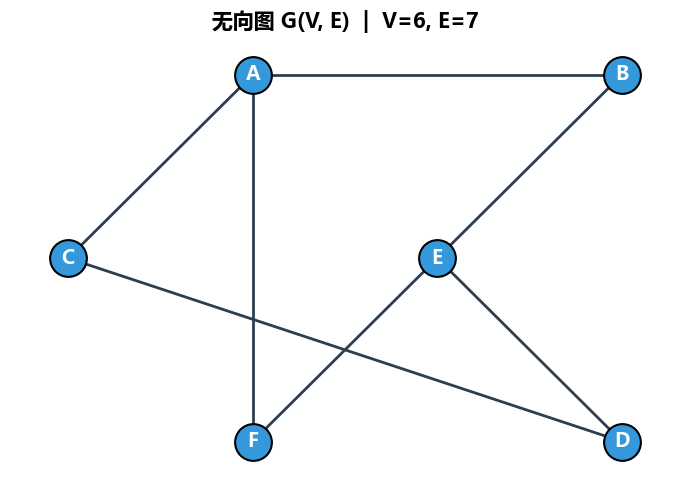

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

G = nx.Graph()
G.add_edges_from(edges)

# 自定义布局
pos = {
    'A': (0, 2),
    'B': (2, 2),
    'C': (-1, 1),
    'D': (2, 0),
    'E': (1, 1),
    'F': (0, 0),
}

plt.figure(figsize=(7, 5))
nx.draw_networkx_edges(G, pos, width=2, edge_color='#2c3e50')
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='#3498db',
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', font_color='white')

plt.title("无向图 G(V, E)  |  V=6, E=7", fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. 总结

### 邻接矩阵
```
    A  B  C  D  E  F
A   0  1  1  0  0  1
B   1  0  0  0  1  0
C   1  0  0  1  0  0
D   0  0  1  0  1  0
E   0  1  0  1  0  1
F   1  0  0  0  1  0
```

### 邻接表
```
  A -> [B, C, F]
  B -> [A, E]
  C -> [A, D]
  D -> [C, E]
  E -> [B, D, F]
  F -> [A, E]
```

### 对比

| 表示法 | 空间复杂度 | 判断边 (u,v) | 遍历邻居 | 适用场景 |
|--------|:----------:|:------------:|:--------:|----------|
| 邻接矩阵 | O(V²) | O(1) | O(V) | 稠密图、频繁查边 |
| 邻接表 | O(V+E) | O(deg(u)) | O(deg(u)) | 稀疏图、遍历邻居 |

本题 |V|=6, |E|=7，属于稀疏图，**邻接表更省空间**。